In [24]:
# ====================================================================
# 0. imports & reproducibility
# ====================================================================
import pandas as pd, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tcn import TCN
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from pathlib import Path
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adamax, Nadam, Adadelta

rng = np.random.default_rng(42)
tf.keras.utils.set_random_seed(42)
tf.debugging.enable_check_numerics()          # crash early on NaN/Inf

INFO:tensorflow:Enabled check-numerics callback in thread MainThread


In [25]:
# ------------------------------------------------------------------
# files you want to merge  (add as many as you like)
# ------------------------------------------------------------------
FILES = [
    "previous_dv0_withstraw_sipCAdded.xlsx", 
    "dv0_withstraw_sipCAdded.xlsx",
                       # ← put your second file name here
    # "third_file.xlsx",
]

In [26]:
# ------------------------------------------------------------------
# read & re-index
# ------------------------------------------------------------------
dfs          = []
next_offset  = 0          # keeps track of the next free Participant_ID

for fp in FILES:
    fp = Path(fp)
    df = pd.read_excel(fp)

    # current file's min/max before shifting (optional print for sanity)
    old_min, old_max = df["Participant_ID"].min(), df["Participant_ID"].max()
    print(f"{fp.name}: original IDs {old_min} … {old_max}")

    # shift IDs so they don't collide with previous files
    df["Participant_ID"] += next_offset

    # update next_offset for the *next* file
    next_offset = df["Participant_ID"].max() + 1

    # done
    dfs.append(df)
    print(f"   shifted to {df['Participant_ID'].min()} … {df['Participant_ID'].max()}")


previous_dv0_withstraw_sipCAdded.xlsx: original IDs 9 … 59
   shifted to 9 … 59
dv0_withstraw_sipCAdded.xlsx: original IDs 1 … 5
   shifted to 61 … 65


In [27]:
# ------------------------------------------------------------------
# combined DataFrame
# ------------------------------------------------------------------
df_all = pd.concat(dfs, ignore_index=True)
print("\nMerged dataframe shape:", df_all.shape)
print("Global Participant_ID range:", df_all["Participant_ID"].min(),
      "…", df_all["Participant_ID"].max())


Merged dataframe shape: (34978, 82)
Global Participant_ID range: 9 … 65


In [28]:
df_all

,Unnamed: 0,Time,Zone_0,Zone_1,Zone_2,Zone_3,Zone_4,Zone_5,Zone_6,Zone_7,...,Container_Weight,drink,temp,prev,next,sip_start,sip_end,sip_id,dV,TOTAL_SIP_TIME
0,0,1747827431000,284,222,261,317,268,310,2246,2378,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
1,1,1747827431200,284,222,248,317,268,310,2246,2337,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
2,2,1747827431400,284,222,248,317,268,310,2246,2378,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
3,3,1747827431600,284,222,248,317,276,310,2246,2337,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
4,4,1747827431800,284,222,248,317,276,310,2246,2337,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34973,4024,1750725782000,1595,1593,1578,1577,1573,1573,1572,1564,...,7.7,water,n,0,0,False,False,5,0.0,0
34974,4025,1750725782200,1595,1593,1578,1577,1573,1573,1572,1564,...,7.7,water,n,0,0,False,False,5,0.0,0
34975,4026,1750725782400,1595,1591,1578,1577,1574,1573,1575,1564,...,7.7,water,n,0,0,False,False,5,0.0,0
34976,4027,1750725782600,1595,1591,1578,1577,1574,1573,1575,1564,...,7.7,water,n,0,0,False,False,5,0.0,0


In [29]:
df = df_all

In [30]:
# print("Label stats  (raw, before scaling)")
# print("  min :", y.min())
# print("  #zeros :", (y == 0).sum())
# print("  any negative? ", (y < 0).any())

In [31]:

# --------------------------------------------------------------------
# user settings
# --------------------------------------------------------------------

BATCH      = 1                                   # 1 = ragged, >1 = padded


In [32]:
# ====================================================================
# 1. load data  ➜  X(list of (T,64)), y(array)   – SKIP zero-volume sips
# ====================================================================
# df = df[df["Label"] == 1]                        # keep only annotated frames

feature_cols = df.columns[2:66]
seq_keys, label_col = ["Participant_ID", "sip_id", "Label"], "dV"

X, y = [], []
skip_count = 0

for _, g in df.groupby(seq_keys, sort=False):
    dV = float(g[label_col].iloc[0])
    label = int(g["Label"].iloc[0])
    if dV == 0.0 and label ==1:                                # ← drop empty sip
        skip_count += 1
        continue
    X.append(g[feature_cols].to_numpy(np.float32))   # (T,64)
    y.append(label)

y = np.array(y, dtype=np.int32)
X = np.array(X, dtype=object)   # each element is still a (T,64) array
print(f"Total samples kept : {len(X)}")
print(f"Zero-volume skipped : {skip_count}")
print("Label stats  → min:", y.min(), "max:", y.max())

Total samples kept : 378
Zero-volume skipped : 0
Label stats  → min: 0 max: 1


In [34]:
X[:1]

array([array([[284., 222., 261., ..., 168., 177., 201.],
              [284., 222., 248., ..., 168., 179., 206.],
              [284., 222., 248., ..., 168., 177., 206.],
              ...,
              [276., 242., 230., ..., 162., 177., 180.],
              [138., 124., 121., ..., 158., 169., 172.],
              [138., 124., 121., ..., 153., 160., 157.]], dtype=float32)],
      dtype=object)

In [35]:
print(type(X))          # <class 'numpy.ndarray'>
print(X.shape)          # (number,)

print(type(X[0]))       # <class 'numpy.ndarray'>
print(X[0].shape)       # (rows, columns)

<class 'numpy.ndarray'>
(378,)
<class 'numpy.ndarray'>
(82, 64)


In [36]:
# ====================================================================
# 2. shuffle whole sips ➜ 80 / 20 split
# ====================================================================
idx = rng.permutation(len(X))
split1 = int(.64 * len(X))          # 64 % train
split2 = int(.80 * len(X))          # next 16 % val
X_train, y_train = X[idx[:split1]], y[idx[:split1]]
X_val,   y_val   = X[idx[split1:split2]], y[idx[split1:split2]]
X_test,  y_test  = X[idx[split2:]], y[idx[split2:]]
print(f"Train {len(X_train)} Val {len(X_val)}  Test {len(X_test)}")
# y_train_s = np.log1p(y_train)        # log1p for numerical safety
# y_val_s   = np.log1p(y_val)
# y_test_s  = np.log1p(y_test)


Train 241 Val 61  Test 76


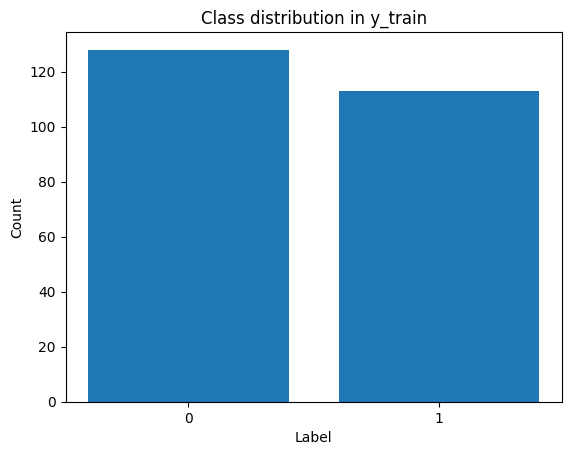

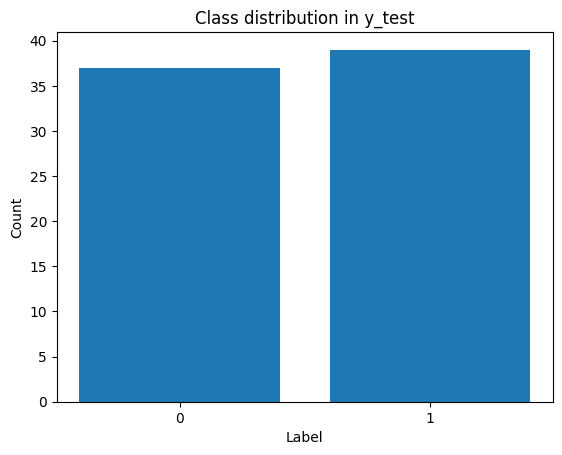

In [ ]:
import matplotlib.pyplot as plt

def plot_class_distribution(y, name="y"):

    unique, counts = np.unique(y, return_counts=True)
    plt.bar([str(u) for u in unique], counts)
    plt.title(f"Class distribution in {name}")
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.show()

# Example usage:
plot_class_distribution(y_train, "y_train")
plot_class_distribution(y_test, "y_test")

In [37]:
# X_train


In [38]:
# y_train

In [39]:
# ====================================================================
# 3. column-wise z-score normalisation (fit on training only)
# ====================================================================
mat_train = np.vstack(X_train)          # ⬅ only TRAIN data
mean64 = mat_train.mean(0, keepdims=True)
std64  = mat_train.std(0,  keepdims=True) + 1e-8

norm = lambda seq: (seq - mean64) / std64
X_train = [norm(s) for s in X_train]
X_val   = [norm(s) for s in X_val]
X_test  = [norm(s) for s in X_test]

# # label scaling
# y_max   = y_train.max() or 1.
# y_train_s = y_train / y_max
# y_val_s   = y_val   / y_max
# y_test_s  = y_test  / y_max
y_train_s = y_train 
y_val_s   = y_val   
y_test_s  = y_test  



In [40]:
# X_train

In [41]:
# ====================================================================
# 4. tf.data pipelines
# ====================================================================
def generator(xs, ys):
    for x, y in zip(xs, ys):
        yield x, y

output_sig = (
    tf.TensorSpec((None, 64), tf.float32),
    tf.TensorSpec((),          tf.float32)
)

def make_ds(xs, ys, shuffle=True):
    ds = tf.data.Dataset.from_generator(lambda: generator(xs, ys),
                                        output_signature=output_sig)
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    if BATCH == 1:
        return ds.repeat().batch(1)              # ragged
    return ds.repeat().padded_batch(             # padded
        BATCH,
        padded_shapes=([None, 64], []),
        padding_values=(0.0, 0.0)
    )

train_ds = make_ds(X_train, y_train_s, shuffle=True)
val_ds   = make_ds(X_val,   y_val_s,   shuffle=False)
test_ds  = make_ds(X_test,  y_test_s,  shuffle=False)

In [42]:
train_ds

<_BatchDataset element_spec=(TensorSpec(shape=(None, None, 64), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>

In [43]:
# for batch in train_ds.take(1):
#     x_batch, y_batch = batch
#     print("x_batch shape:", x_batch.shape)
#     print("y_batch shape:", y_batch.shape)
#     print("x_batch:", x_batch.numpy())
#     print("y_batch:", y_batch.numpy())

In [44]:
num_classes = len(np.unique(y)) 

In [45]:
num_classes

2

In [46]:
y_train

array([1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
      dtype=int32)

In [47]:
# # ====================================================================
# # 5. model  – TCN ➜ Dense(1, softplus) keeps output ≥ 0
# # ====================================================================
# inp = tf.keras.Input(shape=(None, 64))
# x = TCN(nb_filters=128,
#         kernel_size=2,
#         dilations=[1,2,4,8,16,32],   # ~64-time-step field
#         dropout_rate=0.1,
#         return_sequences=False)(inp)
# out = tf.keras.layers.Dense(num_classes, activation="softmax")(x)  # softmax for classification
# model = tf.keras.Model(inp, out)
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(1e-3),
#     loss="sparse_categorical_crossentropy",  # use sparse labels
#     metrics=["accuracy"],                        
# )
# model.summary()

# steps_per_epoch = len(X_train) // BATCH + (len(X_train) % BATCH > 0)
# val_steps       = len(X_val)   // BATCH + (len(X_val)   % BATCH > 0)
# # weights = (y_train / y_train.max()) ** 0.5  
# cb = tf.keras.callbacks.EarlyStopping(
#          monitor='val_loss', patience=15, restore_best_weights=True)
# model.fit(
#     train_ds,
#     epochs=10,
#     steps_per_epoch=steps_per_epoch,
#     validation_data=val_ds,        # ⬅ use VALIDATION set
#     validation_steps=val_steps,
#     verbose=1,
#     # sample_weight=weights,
#     callbacks=[cb]
# )

In [48]:
inp = tf.keras.Input(shape=(None, 64))
x = TCN(
    nb_filters=128,
    kernel_size=2,
    dilations=[1, 2, 4, 8, 16, 32],
    dropout_rate=0.1,
    return_sequences=False
)(inp)
out = tf.keras.layers.Dense(num_classes, activation="softmax")(x)  # 2 units, softmax

model = tf.keras.Model(inp, out)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",  # expects integer labels, 0 or 1
    metrics=["accuracy"],
)
model.summary()

steps_per_epoch = len(X_train) // BATCH + (len(X_train) % BATCH > 0)
val_steps = len(X_val) // BATCH + (len(X_val) % BATCH > 0)

cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True)

model.fit(
    train_ds,
    epochs=50,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=val_steps,
    verbose=1,
    callbacks=[cb]
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn (TCN)                       │ (None, 128)            │       386,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 386,946 (1.48 MB)

 Trainable params: 386,946 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7900 - loss: 5.1539 - val_accuracy: 0.9672 - val_loss: 0.0793
Epoch 2/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8799 - loss: 0.9551 - val_accuracy: 0.9344 - val_loss: 0.1974
Epoch 3/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9519 - loss: 0.1894 - val_accuracy: 0.9508 - val_loss: 0.0948
Epoch 4/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9371 - loss: 0.2813 - val_accuracy: 0.9180 - val_loss: 0.3831
Epoch 5/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9582 - loss: 0.1925 - val_accuracy: 0.9672 - val_loss: 0.1182
Epoch 6/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9979 - loss: 0.0086 - val_accuracy: 0.9836 - val_loss: 0.0747
Epoch 7/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9672 - val_loss: 0.1002
Epoch 8/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9995 - loss: 0.0032 - val_accu

In [49]:
# ====================================================================
# 6. inference on test set (un-scale predictions)
# ====================================================================
# y_pred_s = np.array([model.predict(seq[None, ...], verbose=0)[0, 0]
#                      for seq in X_test])
# inverse transform after prediction
# y_pred_s = np.expm1(y_pred_s)
# y_pred   = y_pred_s * y_max
# Get softmax probabilities for both classes
y_pred_probs = np.array([model.predict(seq[None, ...], verbose=0)[0] for seq in X_test])  # shape: (N, 2)
y_pred = np.argmax(y_pred_probs, axis=1)  # shape: (N,)
# y_pred = np.argmax(y_pred_s)
# y_pred = y_pred_s
y_mean, y_std = y_train.mean(), y_train.std()
y_train_s = (y_train - y_mean) / y_std
# ...
# y_pred = y_pred_s * y_std + y_mean       # undo scaling

In [50]:
y_test

array([1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1], dtype=int32)

In [51]:
y_pred

array([1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1])

In [52]:
# # ====================================================================
# # 7. evaluation
# # ====================================================================
# mse  = mean_squared_error(y_test, y_pred)
# rmse = np.sqrt(mse)
# r2   = r2_score(y_test, y_pred)

# non_zero = y_test != 0
# rmspe = (np.sqrt(np.mean(((y_test[non_zero]-y_pred[non_zero]) /
#                           y_test[non_zero])**2))*100
#          if non_zero.any() else np.nan)

# print(f"\nEvaluation on {len(y_test)} test sips")
# print(f"  MSE   : {mse:.4f}")
# print(f"  RMSE  : {rmse:.4f}")
# print(f"  R²    : {r2:.4f}")
# print(f"  RMSPE : {rmspe:.2f}%")

# comparison_df = pd.DataFrame({"Actual dV": y_test, "Predicted dV": y_pred})
# print("\nFirst 50 predictions:")
# print(comparison_df.head(50))

In [53]:
# # ====================================================================
# # 8. scatter plot
# # ====================================================================
# plt.figure(figsize=(7, 6))
# plt.scatter(y_test, y_pred, alpha=0.7)
# lims = [0, max(y_test.max(), y_pred.max()) * 1.05]
# plt.plot(lims, lims, "r--")
# plt.xlim(lims); plt.ylim(lims)
# plt.xlabel("Actual dV"); plt.ylabel("Predicted dV")
# plt.title("TCN – Actual vs. Predicted Drinking Volume")
# plt.grid(True); plt.tight_layout(); plt.show()

In [54]:
# print("First 5 log targets  :", y_train_s[:5])
# print("First 5 raw targets  :", y_train[:5])

# # after one epoch
# raw_pred = np.expm1(model.predict(X_val[:3])[...,0])
# print("First 3 un-scaled predictions:", raw_pred)

In [55]:
print("train  min / max (ml):", y_train.min(), y_train.max())
print("train_s min / max (log):", y_train_s.min(), y_train_s.max())

# quick expectation check:  ln(1+160) ≈ 5.08
#                           ln(1+  5) ≈ 1.79

train  min / max (ml): 0 1
train_s min / max (log): -0.9395810236483068 1.0643041683803829


y_test shape: (76,)
y_pred shape: (76,)
              precision    recall  f1-score   support

Not Drinking       0.92      0.92      0.92        37
    Drinking       0.92      0.92      0.92        39

    accuracy                           0.92        76
   macro avg       0.92      0.92      0.92        76
weighted avg       0.92      0.92      0.92        76



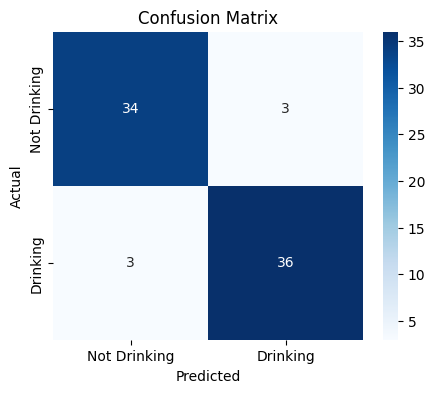

In [56]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Make sure y_pred is 1D integer array
# If you have probabilities, convert to class labels:
# y_pred_probs = model.predict(X_test_padded, verbose=1)
# y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Make sure y_test is also 1D integer array
y_test = np.array(y_test).flatten()
y_pred = np.array(y_pred).flatten()

# 3. Check shapes
print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)

# 4. Confusion matrix and report
cm = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred, target_names=["Not Drinking", "Drinking"]))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Not Drinking", "Drinking"], 
            yticklabels=["Not Drinking", "Drinking"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [57]:
print("y_test unique:", np.unique(y_test), y_test.dtype)
print("y_pred unique:", np.unique(y_pred), y_pred.dtype)

y_test unique: [0 1] int32
y_pred unique: [0 1] int64



Detailed classification metrics (binned regression outputs):
Precision : 0.9211
Recall    : 0.9211
F1-score  : 0.9211


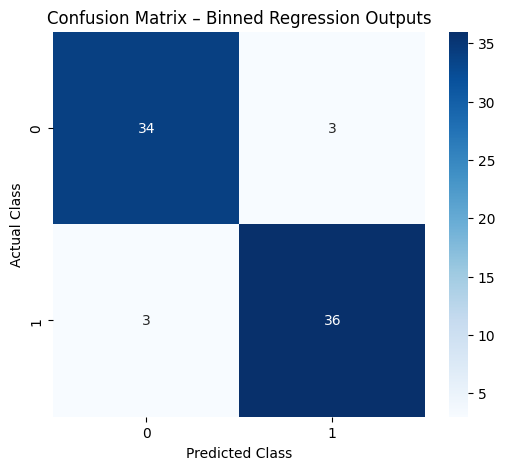

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

# Assume y_test and y_pred are continuous regression outputs

num_classes = 1
bins = np.linspace(min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max()), num_classes + 1)

y_true_classes = np.digitize(y_test, bins) - 1
y_pred_classes = np.digitize(y_pred, bins) - 1

# Fit label encoder on combined classes to avoid unknown label error
le = LabelEncoder()
all_classes = np.concatenate([y_true_classes, y_pred_classes])
le.fit(all_classes)

y_true_encoded = le.transform(y_true_classes)
y_pred_encoded = le.transform(y_pred_classes)

prec = precision_score(y_true_encoded, y_pred_encoded, average='weighted')
rec = recall_score(y_true_encoded, y_pred_encoded, average='weighted')
f1 = f1_score(y_true_encoded, y_pred_encoded, average='weighted')

print('\nDetailed classification metrics (binned regression outputs):')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-score  : {f1:.4f}')

cm = confusion_matrix(y_true_encoded, y_pred_encoded)
labels = le.classes_

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix – Binned Regression Outputs')
plt.show()